In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import torch
import json
import os
from torch_geometric.nn import global_mean_pool
import src.global_config as global_cfg
import src.stats.config as cfg
import src.gnn.config as ecfg
import src.gnn.model as sage
import src.gnn.data_loader as gnnDataLoader
import src.gnn.train as train
import src.gnn.pipeline as pipeline
import src.gnn.analysis as eanalysis
import src.gnn.visualization as eviz
import src.stats.analysis as stat_analysis
import src.stats.visualization as stat_viz

In [53]:
with open("./Data/BN/network_2003.json", "r") as f:
    raw_json = json.load(f)

snapshot_2003 = gnnDataLoader.json_to_pyg_data(raw_json)
print(f"Snapshot creado: {snapshot_2003}")
print(f"Nodos: {snapshot_2003.num_nodes}, Features: {snapshot_2003.num_node_features}")

Snapshot creado: Data(x=[397, 8], edge_index=[2, 396], edge_attr=[396, 1])
Nodos: 397, Features: 8


In [54]:
data = snapshot_2003
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
data = data.to(device)

Usando dispositivo: cuda


In [55]:


model = sage.GraphSAGEEncoder(ecfg.IN_CHANNELS, ecfg.HIDDEN_CHANNELS, ecfg.OUT_CHANNELS, ecfg.DROPOUT_RATE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=ecfg.LR_INITIAL, weight_decay=ecfg.WEIGHT_DECAY)
criterion = torch.nn.BCEWithLogitsLoss()

In [56]:
trained_model = train.train_linkpred(model, data, optimizer,  criterion, device, epochs=200)
trained_model.eval()
with torch.no_grad():
    z = trained_model(data.x, data.edge_index)  # [num_nodes, out_channels]

embeddings = z.cpu().numpy()
print("dimension de embeddings:", embeddings.shape)  # (num_nodes, out_channels)
print(embeddings[0])

items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]  # lista de clusters


Epoch 001 | Loss: 0.6232
Epoch 020 | Loss: 0.4021
Epoch 040 | Loss: 0.3966
Epoch 060 | Loss: 0.3715
Epoch 080 | Loss: 0.3686
Epoch 100 | Loss: 0.3614
Epoch 120 | Loss: 0.3655
Epoch 140 | Loss: 0.3570
Epoch 160 | Loss: 0.3535
Epoch 180 | Loss: 0.3720
Epoch 200 | Loss: 0.3642
dimension de embeddings: (397, 8)
[ -9.390799   7.412112  24.893238  14.747039  16.834358 -22.742123
  15.332144 -18.915037]


In [57]:

# z ya existe, NO usamos z_nodes aquí
ego_mask = gnnDataLoader.get_ego_mask(raw_json).to(device)

# Filtrar solo alters
z_alters = z[ego_mask]

# Nuevo batch: todos los alters pertenecen al mismo grafo
batch_alters = torch.zeros(z_alters.size(0), dtype=torch.long, device=device)

graph_embedding = global_mean_pool(z_alters, batch_alters)

print("Dimension del embedding del grafo (sin ego):", graph_embedding.shape)
print(graph_embedding)


# Crear el vector batch (todos los nodos tienen la etiqueta 0 porque es un solo grafo)
# z es la matriz de embeddings de todos los nodos, es de la forma [No.Nodos, out_channels]
print(z.shape)
#batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

# Hacemos el pooling usando los embeddings de nodos ya entrenados (z)
# El pooling hace un "promedio" en base al tamaño del batch, en nuestro caso
# al poner batch como un tensor llenos de 0's, entonces promedia todos aquellos que tengan como indice 0 (todos los nodos)
#Devuelve una matriz de [1, 16], "comprime" todos los embeddings a uno solo
#graph_embedding = global_mean_pool(z, batch)
print("Dimension del embedding del grafo:", graph_embedding.shape)
print(graph_embedding)

Dimension del embedding del grafo (sin ego): torch.Size([1, 8])
tensor([[-0.0286,  0.0229,  0.0702,  0.0419,  0.0491, -0.0672,  0.0447, -0.0598]],
       device='cuda:0')
torch.Size([397, 8])
Dimension del embedding del grafo: torch.Size([1, 8])
tensor([[-0.0286,  0.0229,  0.0702,  0.0419,  0.0491, -0.0672,  0.0447, -0.0598]],
       device='cuda:0')


In [58]:
#Entrenar red y generar embeddings
historia = pipeline.run_temporal_graphsage(device)

Modo: con memoria
Epoch 001 | Loss: 1.1754
Epoch 020 | Loss: 0.4113
Epoch 040 | Loss: 0.4318
Epoch 060 | Loss: 0.3789
1980 procesado.
Epoch 001 | Loss: 0.4568
Epoch 020 | Loss: 0.4577
Epoch 040 | Loss: 0.3862
Epoch 060 | Loss: 0.4280
1981 procesado.
Epoch 001 | Loss: 0.4254
Epoch 020 | Loss: 0.4537
Epoch 040 | Loss: 0.3993
Epoch 060 | Loss: 0.4494
1982 procesado.
Epoch 001 | Loss: 0.3873
Epoch 020 | Loss: 0.3837
Epoch 040 | Loss: 0.3884
Epoch 060 | Loss: 0.4161
1983 procesado.
Epoch 001 | Loss: 0.4375
Epoch 020 | Loss: 0.4409
Epoch 040 | Loss: 0.3680
Epoch 060 | Loss: 0.3686
1984 procesado.
Epoch 001 | Loss: 0.3673
Epoch 020 | Loss: 0.3768
Epoch 040 | Loss: 0.3573
Epoch 060 | Loss: 0.3679
1985 procesado.
Epoch 001 | Loss: 0.3671
Epoch 020 | Loss: 0.3676
Epoch 040 | Loss: 0.3681
Epoch 060 | Loss: 0.3758
1986 procesado.
Epoch 001 | Loss: 0.3703
Epoch 020 | Loss: 0.3748
Epoch 040 | Loss: 0.3669
Epoch 060 | Loss: 0.3965
1987 procesado.
Epoch 001 | Loss: 0.3650
Epoch 020 | Loss: 0.3693
Epoc

In [59]:
print(graph_embedding.shape)

torch.Size([1, 8])


In [60]:
df_trayectoria = eanalysis.calcular_pca_2d(historia)
eviz.plot_trayectoria_2d(df_trayectoria)

In [61]:
df_flujo = eanalysis.calcular_pca_1d(historia)
eviz.plot_evolucion_pc1(df_flujo)

In [62]:
# Guardar serie PC1 de GraphSAGE por año
df_sage = df_flujo.rename(columns={"y_original": "sage_pc1"}).copy()
df_sage.to_csv(os.path.join(global_cfg.OUTPUT_DIR, "graphsage_pca1.csv"), index=False)
print(f"[OK] Guardado en: {global_cfg.OUTPUT_DIR}")

[OK] Guardado en: ./Output


Calculando promedios anuales de los datos crudos...
Se invirtió el signo de PC1 para alinearlo con 'Percent of documents'. Corr original: -0.8475

Resultados de Correlación con el Eje Y PC1
WoS Categories: -0.7116
Document Types: -0.4418
Documents,: -0.4633
Ave. citations: 0.2938
Ave. authorships: -0.4103
Ave. references: 0.5973
Percent of documents: 0.8475
Percent of documents Int. Coll.: 0.1783


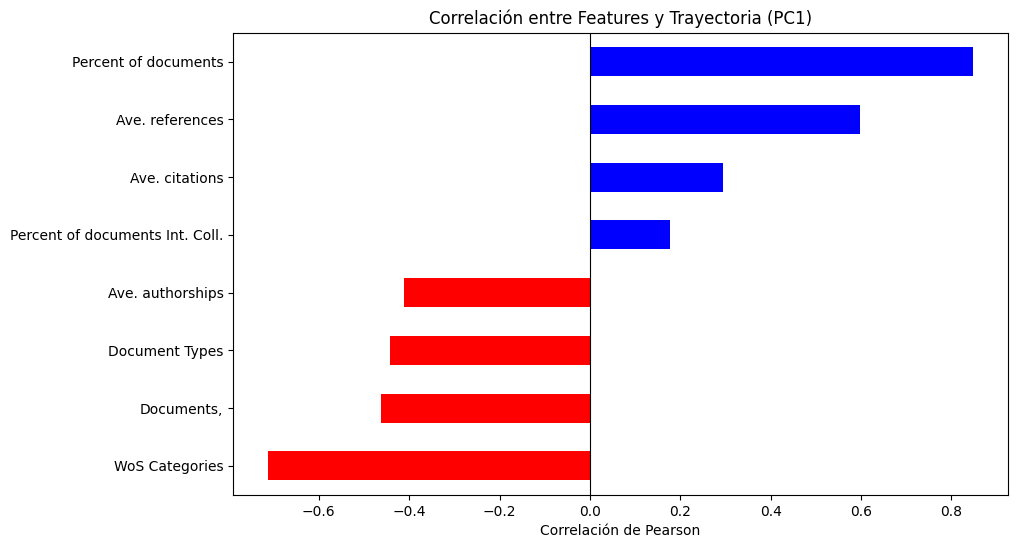

In [63]:
nombres_features = [f[1] for f in global_cfg.FEATURES]
df_features = eanalysis.obtener_promedios_anuales(df_flujo['year'].values, nombres_features, global_cfg.DATA_FOLDER)
df_flujo, correlaciones = eanalysis.correlacionar_y_alinear(df_flujo, df_features, ecfg.ALIGN_PC1_ANCHOR)

eviz.plot_correlaciones_barras(correlaciones)

In [64]:
print(df_features)

      WoS Categories  Document Types  Documents,  Ave. citations  \
1980        3.653846        1.461538    5.182692       48.593558   
1981        3.794521        1.589041    5.136986      197.000685   
1982        4.323077        1.600000    6.815385       31.194769   
1983        4.371429        1.514286    7.580952       50.800286   
1984        3.818182        1.428571    5.246753       42.164675   
1985        4.646552        1.577586    7.974138       40.455345   
1986        5.026490        1.695364    7.692053       24.868576   
1987        4.812500        1.610577   10.216346       27.318269   
1988        5.051829        1.795732    8.588415       30.537226   
1989        4.664032        1.573123    6.640316       26.813083   
1990        5.092179        1.712291   10.497207       33.567877   
1991        4.903654        1.617940    7.401993       29.504718   
1992        5.409195        1.705747    9.997701       20.997057   
1993        4.587859        1.648562    8.964856

In [65]:
#Percent of documents resultó  tener una correlación bastante alta, por lo tanto, las gráficas
#deberían ser bastante parecidas (la generada por pca y la que es a partir de los datos crudos)
#"Ave. authorships"
# 5. Gráficas de Comparación
df_plot, df_comparacion = eanalysis.preparar_datos_comparacion(df_features, df_flujo)
eviz.plot_feature_individual(df_plot, ecfg.ALIGN_PC1_ANCHOR)
eviz.plot_comparacion_normalizada(df_comparacion)

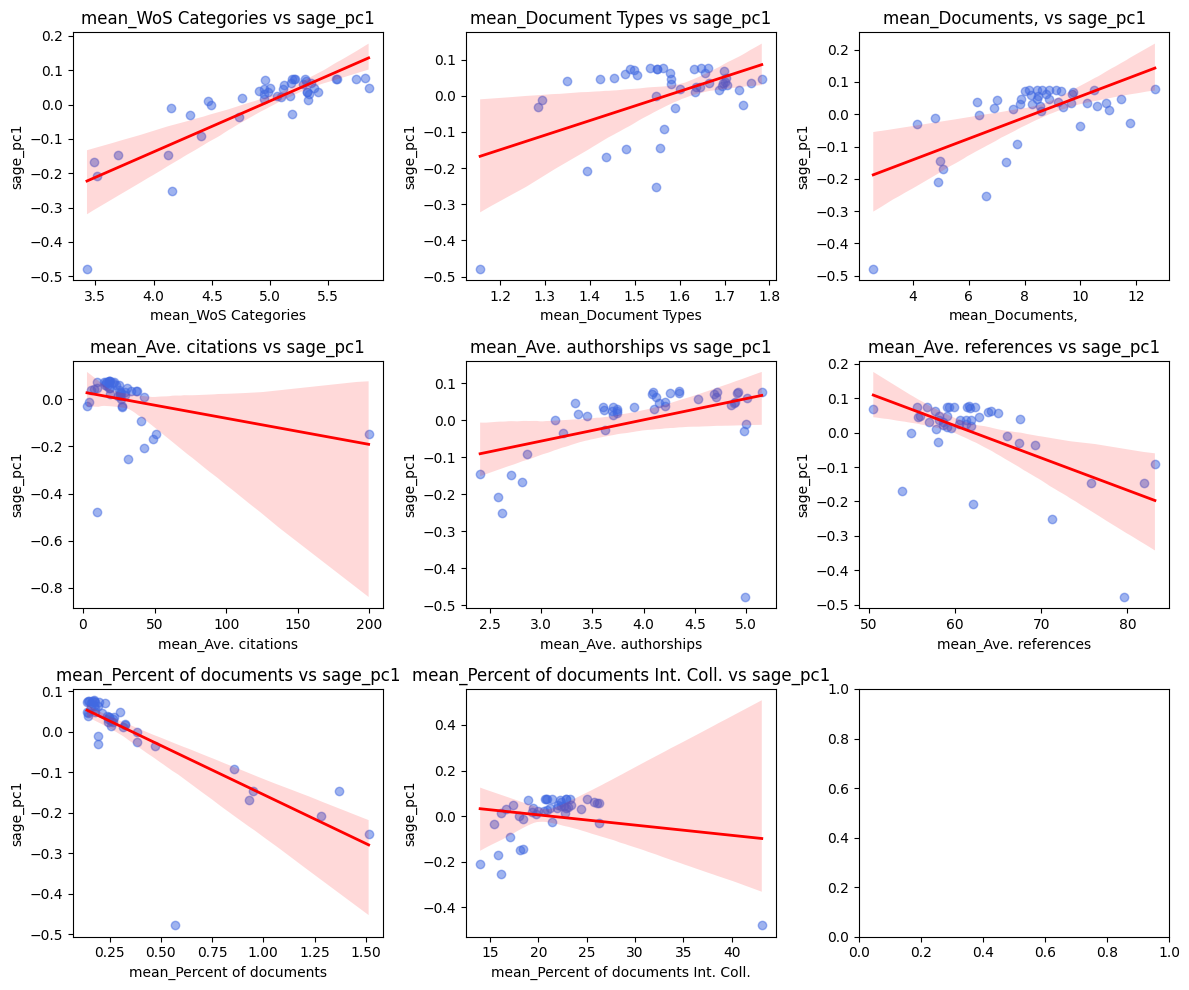

In [66]:
df_all = stat_analysis.cargar_y_unir_datos(cfg.LEVEL) #cargamos y preparamos los datos
#Exploración visual inicial
stat_viz.plot_dispersion_ols(df_all, 'mean_Percent of documents', 'sage_pc1')
# Los candidatos son exactamente los features definidos para hacer el embedding de sage
features_candidatas = [f"mean_{tupla[1]}" for tupla in global_cfg.FEATURES] # Extraemos el segundo elemento de la tupla (tupla[1]) y le pegamos "mean_"
stat_viz.plot_matriz_features(df_all, features_candidatas)

In [67]:
# Modelos OLS
# Múltiple sin HAC
modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. authorships'])
print(modelo_mult.summary())
#y = df_all['sage_pc1']  #variable objetivo
#X = df_all[['mean_Percent of documents', 'mean_Ave. authorships']] #Variables predictoras

# Le ponemos su constante 
#Ecuacion lineal de la forma y=b0 + b1x1 + b2x2 donde los xn son los atributos
#X = sm.add_constant(X) #cada atributo definido en X es un valor asociado a x_n, b0 es la constante (lo definimos como 1), b1 y b2 son los valores a estimar
#modelo = sm.OLS(y, X).fit()
#print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     38.51
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           3.16e-10
Time:                        21:52:37   Log-Likelihood:                 60.366
No. Observations:                  45   AIC:                            -114.7
Df Residuals:                      42   BIC:                            -109.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [68]:

# Múltiple sin HAC
modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. authorships'])
print(modelo_mult.summary())


                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     38.51
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           3.16e-10
Time:                        21:52:37   Log-Likelihood:                 60.366
No. Observations:                  45   AIC:                            -114.7
Df Residuals:                      42   BIC:                            -109.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [69]:
# Simple con HAC
modelo_simple = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents'], usar_hac=True, maxlags=3)
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     70.02
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.44e-10
Time:                        21:52:37   Log-Likelihood:                 56.389
No. Observations:                  45   AIC:                            -108.8
Df Residuals:                      43   BIC:                            -105.2
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

------------------------------------------------------------
Diagnostico de residuos
------------------------------------------------------------
Prueba de Durbin-Watson (Independencia): 0.771
Prueba de Shapiro-Wilk (Normalidad): p-value = 0.0000
Prueba de Breusch-Pagan (Homocedasticidad): p-value = 0.4354


/home/jose/miniconda3/envs/pateaAbuelitas/lib/python3.10/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.



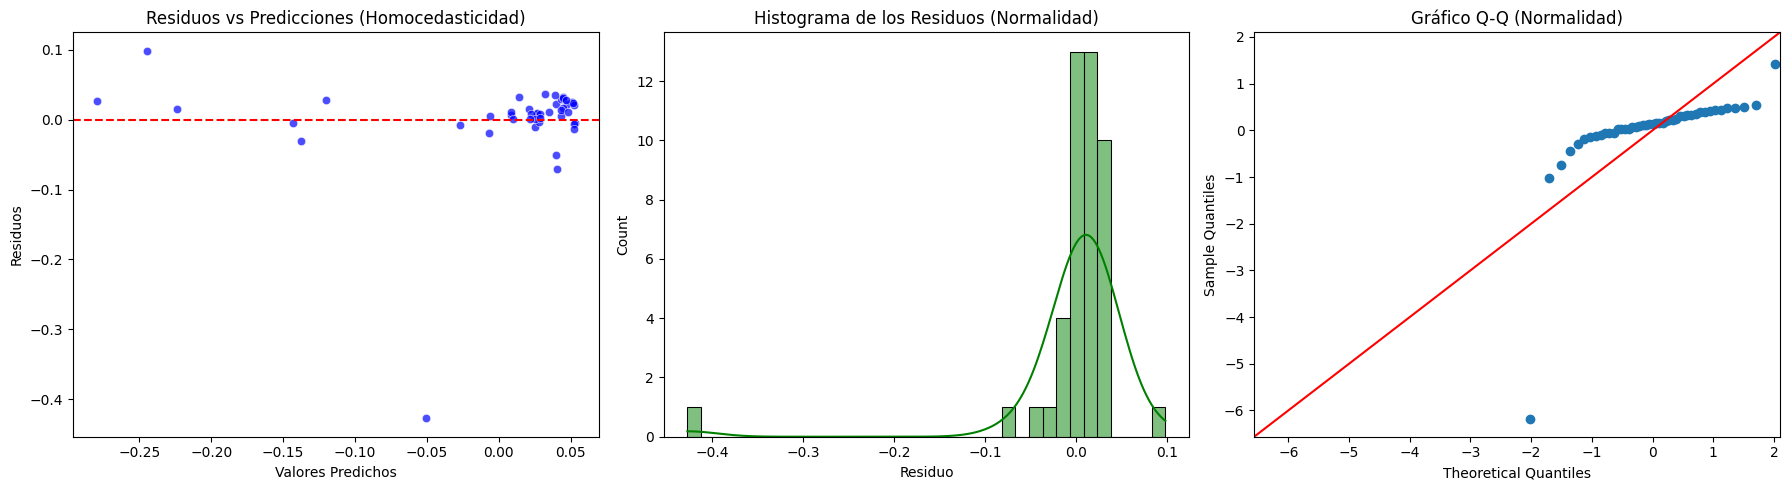

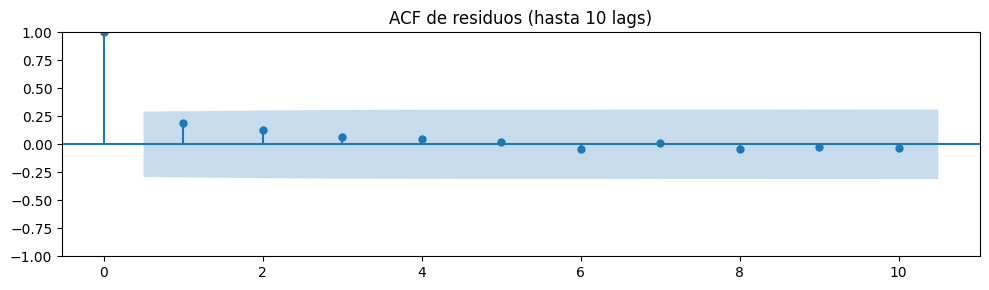

In [70]:
# Diagnóstico de residuos (del modelo simple normal para ver los errores puros)
modelo_base = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents'])
residuos, predicciones = stat_analysis.ejecutar_diagnostico_residuos(modelo_base)

stat_viz.plot_panel_residuos(predicciones, residuos)
stat_viz.plot_acf_residuos(df_all, residuos)